In [3]:
import os
import sys
import shutil
import math
import warnings
import datetime
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from typing import *
from enum import Enum
from scipy.spatial import Voronoi
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import LabelEncoder
from scipy.stats import wasserstein_distance
sys.path.append("/home/esraan/CellDeathSpreading/")
from src.utils import get_experiment_cell_death_times_by_specific_siliding_window,read_experiment_cell_xy_and_death_times
from src.NucleationAndPropagationMeasurements import replace_ugly_long_name
from src.quanta_utils import get_neighbors
from src.DeathQuanta import DeathQuanta

In [7]:
exps_dir_name = "/sise/assafzar-group/assafzar/Esraa/FullFOVsData/OldDataYishaia/Experiments_XYT_CSV/OriginalTimeMinutesData/"
meta_data_file_full_path= "/sise/assafzar-group/assafzar/Esraa/FullFOVsData/OldDataYishaia/Experiments_XYT_CSV/ExperimentsMetaData.csv"
meta_data_extract_exp_names= pd.read_csv(meta_data_file_full_path)
exp_names = meta_data_extract_exp_names.iloc[:,1]
group_data = {}
for idx in range(len(exp_names)):
    if "compressed" in exp_names[idx] or "compressed" in exp_names[idx].lower():
        continue
    try: 
        print(exp_names[idx])
        exp_full_path = os.path.join(exps_dir_name, exp_names[idx])
        csv_file = pd.read_csv(exp_full_path)
        dist_threshold = 100 # microns
        cells_location = csv_file[["cell_x","cell_y"]].values
        di_times = csv_file[['death_time']].values
        death_modes = csv_file[["Mode"]].values if "Mode" in csv_file.columns else []
        name = replace_ugly_long_name(meta_data_extract_exp_names[meta_data_extract_exp_names['File Name']==exp_names[idx]]["Treatment"].values[0],
                            meta_data_extract_exp_names[meta_data_extract_exp_names['File Name']==exp_names[idx]]["Cell Line"].values[0])
        de_qu = DeathQuanta(cells_xy=cells_location,
                            death_times=di_times, 
                            death_modes=death_modes,
                            dist_threshold=dist_threshold,
                            filter_neighbors_by_distance=True,
                            neighbors_level=1,
                            pure_type = name)
        tod_pairs_1 = de_qu.get_org_deltaTOD_neighbors_pairs()
        if name not in group_data:
            group_data[name] = {}
        group_data[name][exp_names[idx]]= tod_pairs_1 # tod_pairs_1.get('apoptosis', []) + tod_pairs_1.get('necrosis', []) if isinstance(tod_pairs_1, dict) else tod_pairs_1
    except Exception as e:
        continue

20160820_10A_FB_xy11.csv
20160820_10A_FB_xy12.csv
20160820_10A_FB_xy13.csv
20160820_10A_FB_xy14.csv
20160820_10A_FB_xy15.csv
20160828_10AsgCx43_FB_xy01.csv
20160828_10AsgCx43_FB_xy02.csv
20160828_10AsgCx43_FB_xy03.csv
20160828_10AsgCx43_FB_xy04.csv
20160828_10AsgCx43_FB_xy05.csv
20160828_10AsgCx43_FB_xy06.csv
20160828_10AsgCx43_FB_xy07.csv
20160828_10AsgCx43_FB_xy08.csv
20160828_10AsgCx43_FB_xy09.csv
20160828_10AsgCx43_FB_xy10.csv
20160828_10AsgCx43_FB_xy11.csv
20160828_10AsgCx43_FB_xy13.csv
20160828_10Awt_FB_xy01.csv
20160828_10Awt_FB_xy02.csv
20160828_10Awt_FB_xy03.csv
20160828_10Awt_FB_xy04.csv
20160828_10Awt_FB_xy05.csv
20160909_b16f10_aMSH_xy36.csv
20160909_b16f10_aMSH_xy37.csv
20160909_b16f10_aMSH_xy38.csv
20160909_b16f10_aMSH_xy39.csv
20160909_b16f10_aMSH_xy40.csv
20161129_MCF7_FB_xy11.csv
20161129_MCF7_FB_xy12.csv
20161129_MCF7_FB_xy13.csv
20161129_MCF7_FB_xy14.csv
20161129_MCF7_FB_xy15.csv
20170213_U937_FB_xy1.csv
20170213_U937_FB_xy2.csv
20170213_U937_FB_xy3.csv
20170213_U937

In [24]:
group_data.get('U937+rpmi+20ng/ml tnfa+1um smac + 20um zvad')

{'20180905_U937_TSZ_xy1.csv': [array([540]),
  array([960]),
  array([240]),
  array([180]),
  array([660]),
  array([900]),
  array([1020]),
  array([1260]),
  array([900]),
  array([1260]),
  array([240]),
  array([300]),
  array([900]),
  array([60]),
  array([60]),
  array([300]),
  array([240]),
  array([960]),
  array([960]),
  array([420]),
  array([240]),
  array([1080]),
  array([60]),
  array([120]),
  array([420]),
  array([300]),
  array([780]),
  array([1080]),
  array([900]),
  array([60]),
  array([1140]),
  array([660]),
  array([1140]),
  array([60]),
  array([900]),
  array([120]),
  array([120]),
  array([960]),
  array([60]),
  array([180]),
  array([60]),
  array([60]),
  array([540]),
  array([0]),
  array([540]),
  array([0]),
  array([60]),
  array([1020]),
  array([780]),
  array([900]),
  array([420]),
  array([900]),
  array([180]),
  array([420]),
  array([780]),
  array([240]),
  array([660]),
  array([660]),
  array([780]),
  array([120]),
  array([660]),


In [25]:
group_data.pop('U937+rpmi+20ng/ml tnfa+1um smac + 20um zvad')

{'20180905_U937_TSZ_xy1.csv': [array([540]),
  array([960]),
  array([240]),
  array([180]),
  array([660]),
  array([900]),
  array([1020]),
  array([1260]),
  array([900]),
  array([1260]),
  array([240]),
  array([300]),
  array([900]),
  array([60]),
  array([60]),
  array([300]),
  array([240]),
  array([960]),
  array([960]),
  array([420]),
  array([240]),
  array([1080]),
  array([60]),
  array([120]),
  array([420]),
  array([300]),
  array([780]),
  array([1080]),
  array([900]),
  array([60]),
  array([1140]),
  array([660]),
  array([1140]),
  array([60]),
  array([900]),
  array([120]),
  array([120]),
  array([960]),
  array([60]),
  array([180]),
  array([60]),
  array([60]),
  array([540]),
  array([0]),
  array([540]),
  array([0]),
  array([60]),
  array([1020]),
  array([780]),
  array([900]),
  array([420]),
  array([900]),
  array([180]),
  array([420]),
  array([780]),
  array([240]),
  array([660]),
  array([660]),
  array([780]),
  array([120]),
  array([660]),


/tmp/ipykernel_1289265/496661313.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='GroupLabel', y='Difference', data=df,
/tmp/ipykernel_1289265/496661313.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, fontsize=12, rotation=90, ha='right')


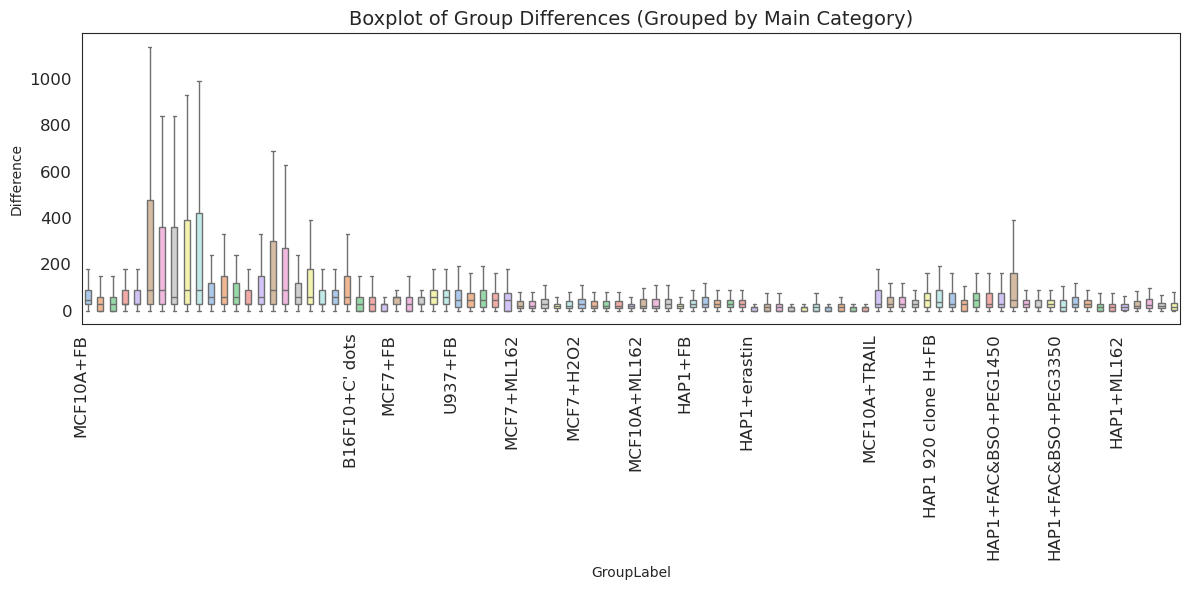

In [27]:
# Sort groups hierarchically
df['MainGroup'] = df['Group'].apply(lambda x: x.split('/')[0])
df['SubGroup'] = df['Group'].apply(lambda x: x.split('/')[1] if '/' in x else x)
df['GroupLabel'] = df['MainGroup'] + ':\n' + df['SubGroup']

# Plot boxplot
plt.figure(figsize=(12, 6))
sns.set_style("white") 
ax = sns.boxplot(x='GroupLabel', y='Difference', data=df,
                 width=0.5, palette='pastel', showfliers=False)

# Replace subgroup labels with main group labels only once per group
group_labels = df['GroupLabel'].unique()
main_groups = [label.split(':\n')[0] for label in group_labels]

# Build condensed label list where each main group appears only at first index
x_labels = []
seen = set()
for g in main_groups:
    if g not in seen:
        x_labels.append(g)
        seen.add(g)
    else:
        x_labels.append("")

# Apply the new tick labels
ax.set_xticklabels(x_labels, fontsize=12, rotation=90, ha='right')

# Continue formatting
plt.yticks(fontsize=12)
plt.title('Boxplot of Group Differences (Grouped by Main Category)', fontsize=14)
plt.ylabel('Difference')
plt.grid(False)
plt.tight_layout()
plt.savefig("/home/esraan/CellDeathSpreading/results/boxplot_hierarchical.svg", format="svg", dpi=300)
plt.show()


In [51]:
# Filter outliers using IQR per subgroup
def filter_outliers_iqr(sub_df):
    q1 = sub_df['Difference'].quantile(0.25)
    q3 = sub_df['Difference'].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return sub_df[(sub_df['Difference'] >= lower_bound) & (sub_df['Difference'] <= upper_bound)]

# Apply filtering to each subgroup
df_filtered = df.groupby('GroupLabel', group_keys=False).apply(filter_outliers_iqr)


/tmp/ipykernel_1289265/1174549473.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_filtered = df.groupby('GroupLabel', group_keys=False).apply(filter_outliers_iqr)


/tmp/ipykernel_1289265/1982858112.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='GroupLabel', y='Difference', data=df_filtered,


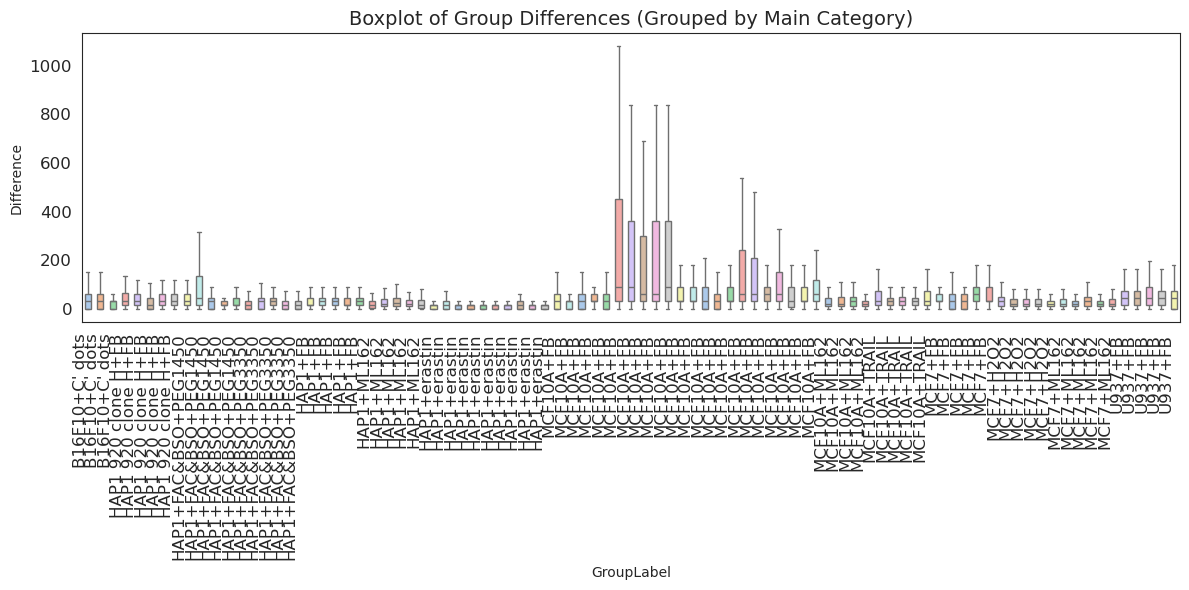

In [52]:
# Sort groups hierarchically
df_filtered['MainGroup'] = df_filtered['Group'].apply(lambda x: x.split('/')[0])
df_filtered['SubGroup'] = df_filtered['Group'].apply(lambda x: x.split('/')[1] if '/' in x else x)
df_filtered['GroupLabel'] = df_filtered['MainGroup'] + ':\n' + df_filtered['SubGroup']

# Plot boxplot
plt.figure(figsize=(12, 6))
sns.set_style("white")
ax = sns.boxplot(x='GroupLabel', y='Difference', data=df_filtered,
                 width=0.5, palette='pastel', showfliers=False)

# Get all unique group labels
group_labels = df_filtered['GroupLabel'].unique()
# Repeat main group label for every boxplot
repeated_main_labels = [label.split(':\n')[0] for label in group_labels]

# Set tick positions and labels
tick_positions = np.arange(len(group_labels))
ax.set_xticks(tick_positions)
ax.set_xticklabels(repeated_main_labels, fontsize=12, rotation=90, ha='right')

# Optional: draw tick marks
ax.tick_params(axis='x', which='both', length=5)

# Final formatting
plt.yticks(fontsize=12)
plt.title('Boxplot of Group Differences (Grouped by Main Category)', fontsize=14)
plt.ylabel('Difference')
plt.grid(False)
plt.tight_layout()
plt.savefig("/home/esraan/CellDeathSpreading/results/boxplot_mainlabels_repeated_no_outlier.svg", format="svg", dpi=300)
plt.show()


/tmp/ipykernel_1289265/2750781002.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='GroupLabel', y='Difference', data=df,


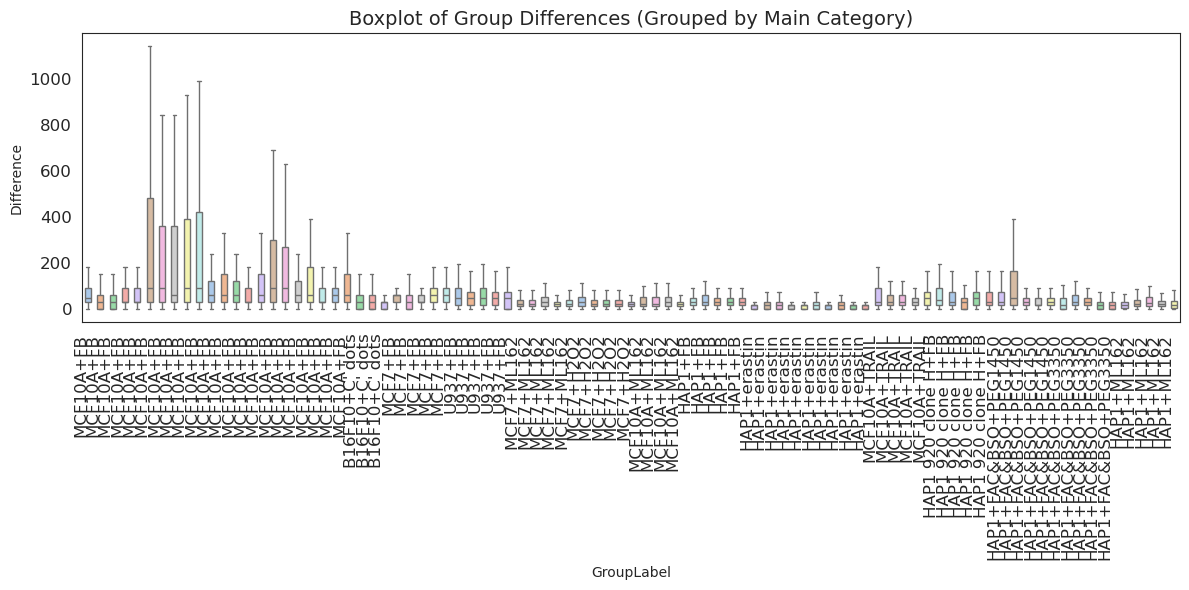

In [53]:
# Sort groups hierarchically
df['MainGroup'] = df['Group'].apply(lambda x: x.split('/')[0])
df['SubGroup'] = df['Group'].apply(lambda x: x.split('/')[1] if '/' in x else x)
df['GroupLabel'] = df['MainGroup'] + ':\n' + df['SubGroup']

# Plot boxplot
plt.figure(figsize=(12, 6))
sns.set_style("white")
ax = sns.boxplot(x='GroupLabel', y='Difference', data=df,
                 width=0.5, palette='pastel', showfliers=False)

# Get all unique group labels
group_labels = df['GroupLabel'].unique()
# Repeat main group label for every boxplot
repeated_main_labels = [label.split(':\n')[0] for label in group_labels]

# Set tick positions and labels
tick_positions = np.arange(len(group_labels))
ax.set_xticks(tick_positions)
ax.set_xticklabels(repeated_main_labels, fontsize=12, rotation=90, ha='right')

# Optional: draw tick marks
ax.tick_params(axis='x', which='both', length=5)

# Final formatting
plt.yticks(fontsize=12)
plt.title('Boxplot of Group Differences (Grouped by Main Category)', fontsize=14)
plt.ylabel('Difference')
plt.grid(False)
plt.tight_layout()
plt.savefig("/home/esraan/CellDeathSpreading/results/boxplot_mainlabels_repeated_correct.svg", format="svg", dpi=300)
plt.show()


/tmp/ipykernel_1289265/449565903.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='GroupLabel', y='Difference', data=df,


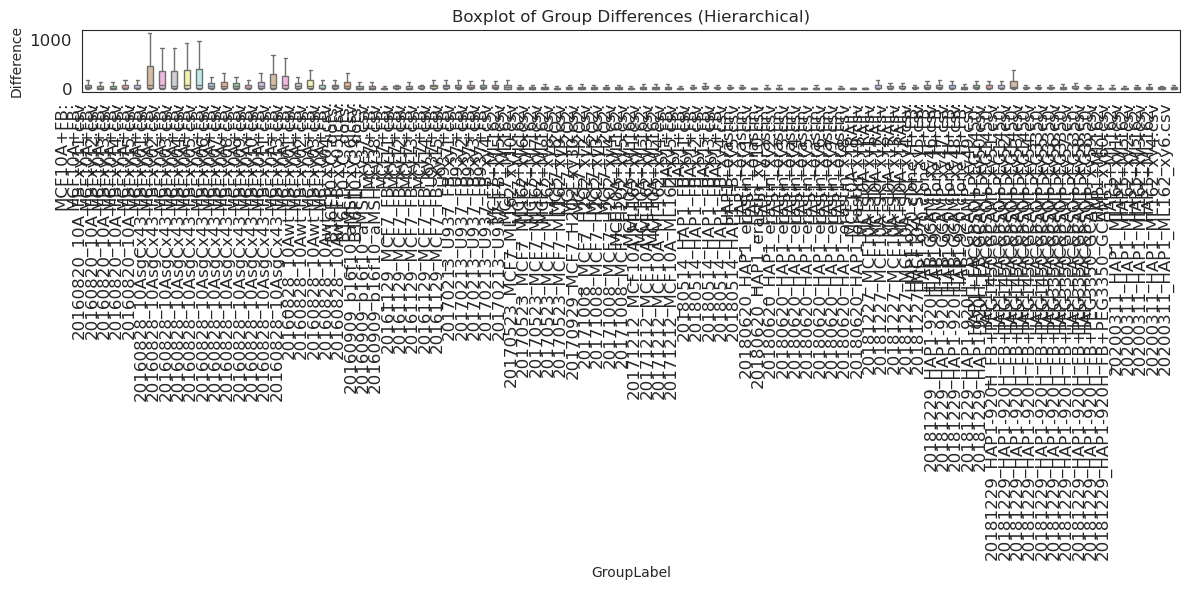

In [35]:
flattened_data = {'Group': [], 'Difference': []}
# Remove "entosis" from group_data
filtered_group_data = {}
for group_name, subgroups in group_data.items():
    if isinstance(subgroups, dict):  # Check if subgroups exist
        filtered_subgroups = {subgroup_name: arrays for subgroup_name, arrays in subgroups.items() if subgroup_name != "entosis"}
        if filtered_subgroups:  # Add only if there are remaining subgroups
            filtered_group_data[group_name] = filtered_subgroups
    else:
        filtered_group_data[group_name] = subgroups  # Keep flat structure unchanged

group_data = filtered_group_data

for group_name, value in group_data.items():
    if isinstance(value, dict):  # Nested: group → subgroup → arrays
        for subgroup_name, arrays in value.items():
            label = f"{group_name}/{subgroup_name}"
            for arr in arrays:
                flattened_data['Group'].extend([label] * len(arr))
                flattened_data['Difference'].extend(arr)
    else:  # Flat list of arrays
        for arr in value:
            flattened_data['Group'].extend([group_name] * len(arr))
            flattened_data['Difference'].extend(arr)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.DataFrame(flattened_data)

# Sort groups hierarchically
df['MainGroup'] = df['Group'].apply(lambda x: x.split('/')[0])
df['SubGroup'] = df['Group'].apply(lambda x: x.split('/')[1] if '/' in x else x)
df['GroupLabel'] = df['MainGroup'] + ':\n' + df['SubGroup']  # for axis formatting

# Plot boxplot
plt.figure(figsize=(12, 6))
sns.set_style("white") 
sns.boxplot(x='GroupLabel', y='Difference', data=df,
            width=0.5, palette='pastel', showfliers=False)

# Annotate quartiles
for i, label in enumerate(df['GroupLabel'].unique()):
    values = df[df['GroupLabel'] == label]['Difference']
    median = np.median(values)
    q1 = np.percentile(values, 25)
    q3 = np.percentile(values, 75)

    # Annotate: uncomment if needed
    # plt.text(i, median, f'{median:.2f}', va='center', ha='right', fontsize=9, color='black')
    # plt.text(i, q1, f'{q1:.2f}', va='center', ha='right', fontsize=9, color='blue')
    # plt.text(i, q3, f'{q3:.2f}', va='center', ha='right', fontsize=9, color='red')
plt.xticks(fontsize=12, rotation=90, ha='right',ticks=range(len(df['GroupLabel'].unique())))
plt.yticks(fontsize=12)
# Format plot
# plt.xticks(rotation=90, ha='right')
plt.title('Boxplot of Group Differences (Hierarchical)')
plt.ylabel('Difference')
plt.grid(False)#, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("/home/esraan/CellDeathSpreading/results/boxplot_hierarchical.svg", format="svg", dpi=300)
plt.show()
# Save the plot as a high-resolution image suitable for Adobe Illustrator



# Clustering

In [54]:
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import fcluster

# Extract the 'Difference' column from df_filtered for clustering
X = df_filtered['Difference'].values.reshape(-1, 1)

# Compute the distance matrix
distance_matrix = pdist(X, metric='euclidean')

# Perform hierarchical clustering
Z = linkage(distance_matrix, method='ward')

# Plot the dendrogram
plt.figure(figsize=(10, 6))
dendrogram(Z, labels=df_filtered['GroupLabel'].values, leaf_rotation=90)
plt.title("Hierarchical Clustering Dendrogram")
plt.show()

# Assign cluster labels
n_clusters = 4  # or use a distance threshold instead
cluster_labels = fcluster(Z, t=n_clusters, criterion='maxclust')


: 

In [ ]:
from sklearn.metrics import silhouette_score
score = silhouette_score(X, cluster_labels, metric='euclidean')
print("Silhouette score:", score)


In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency

contingency = pd.crosstab(cluster_labels, G)
chi2, p, dof, expected = chi2_contingency(contingency)
print("Chi² statistic =", chi2, ", p-value =", p)


In [ ]:
from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(G, cluster_labels)
print("Adjusted Rand Index:", ari)
